In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from config.env_config import Config
from env_nikolai1 import UniswapV3LPGymEnv 

In [2]:
import numpy as np

TICK_MIN = -887_272
TICK_MAX =  887_272

def random_action():

    a0 = np.random.randint(0, 2)                         # 0 or 1
    tick_lower = np.random.randint(TICK_MIN, TICK_MAX)   # inclusive
    tick_upper = np.random.randint(tick_lower + 1, TICK_MAX + 1)
    return np.array([a0, tick_lower, tick_upper], dtype=np.float32)

In [3]:
cfg   = Config()
env   = UniswapV3LPGymEnv(cfg)

state, _ = env.reset()

steps                 = 500
cumulative_pnl_hist   = [env.cumulative_pnl]
time_steps            = [0]

for t in tqdm(range(steps), desc="Simulating"):
    action = random_action()           
    state, reward, done, truncated, info = env.step(action)
    cumulative_pnl_hist.append(env.cumulative_pnl)
    time_steps.append(t + 1)

env.close()

Simulating: 100%|██████████| 500/500 [00:00<00:00, 1451.27it/s]


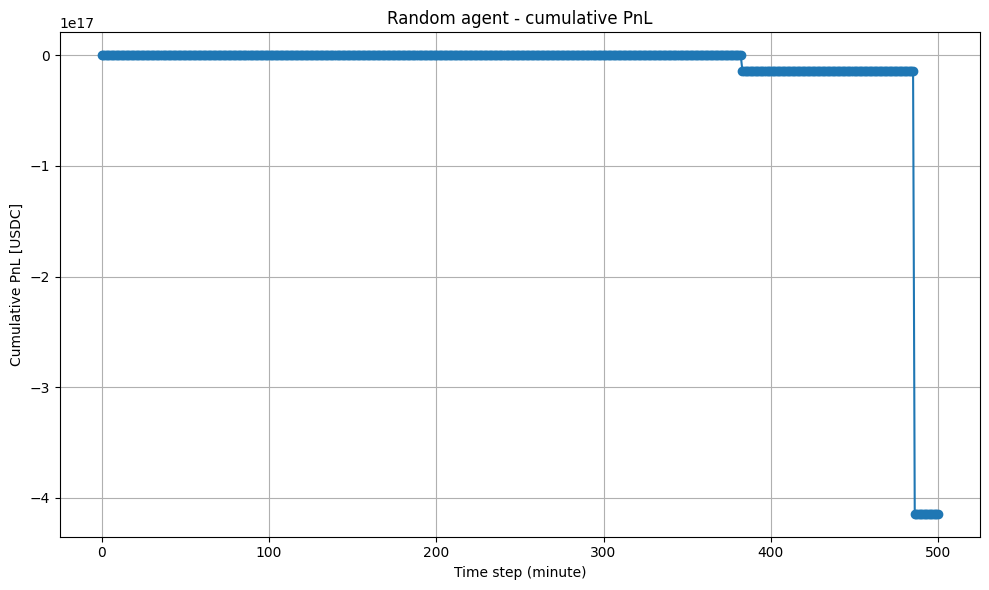

In [4]:
# ──────────────────────────────────────────────────────────────────────────
# 4.  Plot
# ──────────────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
plt.plot(time_steps, cumulative_pnl_hist, marker="o")
plt.xlabel("Time step (minute)")
plt.ylabel("Cumulative PnL [USDC]")
plt.title("Random agent - cumulative PnL")
plt.grid(True)
plt.tight_layout()
plt.show()

# RL Exper

In [ ]:
!pip install stable-baselines3

In [ ]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)   

from env_nikolai1 import UniswapV3LPGymEnv     
from config.env_config import Config     

import gymnasium as gym
from gymnasium.wrappers import TimeLimit, RecordEpisodeStatistics, FlattenObservation
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecTransposeImage
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy

import matplotlib.pyplot as plt
import numpy as np
import os, json, torch, argparse, datetime as dt


# ╭─────────────────────────────  Helpers ─────────────────────────────╮
def make_env():

    cfg = Config()                          # edit defaults if you like
    env = UniswapV3LPGymEnv(cfg, feat_num=19)

    max_steps = 1 * 24 * 60                 # 1440 steps ≈ 1 day
    env = TimeLimit(env, max_episode_steps=max_steps)

    env = RecordEpisodeStatistics(env)
    env = FlattenObservation(env)           # PPO expects flat array

    # Folder for logs & tmp files
    logs_dir = Path("logs");  logs_dir.mkdir(exist_ok=True)
    env = Monitor(env, logs_dir, allow_early_resets=True)

    return env


def plot_learning_curve(monitor_csv, title="Learning curve"):
    """
    Reads rewards from Monitor file and plots rolling mean.
    """
    import pandas as pd
    df = pd.read_csv(monitor_csv, comment="#")
    df["rolling_return"] = df["r"].rolling(window=20).mean()

    plt.figure(figsize=(8, 4))
    plt.plot(df["l"], df["rolling_return"])
    plt.xlabel("Episode");  plt.ylabel("Reward (20-ep MA)")
    plt.title(title);  plt.grid(True)
    plt.tight_layout()
    plt.show()


# ╭─────────────────────────────  Training ────────────────────────────╮
def main(args):
    # --- vectorised env ------------------------------------------------
    env = DummyVecEnv([make_env])

    # --- agent ---------------------------------------------------------
    model = PPO(
        policy           = "MlpPolicy",
        env              = env,
        n_steps          = 2048,
        batch_size       = 256,
        gae_lambda       = 0.95,
        gamma            = 0.999,
        ent_coef         = 0.0,
        learning_rate    = 3e-4,
        vf_coef          = 0.5,
        clip_range       = 0.2,
        verbose          = 1,
        tensorboard_log  = "tensorboard",
        device           = "auto",
    )

    total_timesteps = args.timesteps
    model.learn(total_timesteps=total_timesteps, progress_bar=True)

    timestamp = dt.datetime.now().strftime("%Y%m%d_%H%M")
    model_path = Path("models") / f"ppo_uniswap_{timestamp}"
    model_path.parent.mkdir(exist_ok=True)
    model.save(model_path)
    print(f"\n✔️  Saved to: {model_path}.zip")

    mean_r, std_r = evaluate_policy(model, env, n_eval_episodes=10, return_episode_rewards=False)
    print(f"Evaluation over 10 episodes — mean ± std reward: {mean_r:.2f} ± {std_r:.2f}")

    monitor_files = list(Path("logs").glob("*.monitor.csv"))
    if monitor_files:
        plot_learning_curve(monitor_files[-1], title="PPO on Uniswap-V3 LP env")
    else:
        print("(!) No monitor file found, nothing to plot.")


if __name__ == "__main__":
    # parser = argparse.ArgumentParser()
    # parser.add_argument("--timesteps", type=int, default=500_000,
    #                     help="total training timesteps")
    main([])